In [ ]:
from __future__ import annotations
import copy
import gc
import importlib
import math
import os
import random
import re
import subprocess
import sys
import zipfile
from dataclasses import asdict, dataclass, field, fields
from pathlib import Path
from typing import Any, Callable, Dict, List, MutableMapping, Optional, Sequence, Tuple
from urllib.request import urlretrieve
import yaml
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torch.amp import GradScaler, autocast
from torch.utils.data import DataLoader, Dataset
from torch.utils.data.distributed import DistributedSampler

def _ensure(pkg, pip_name=None):
    try:
        importlib.import_module(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name or pkg])

for _pkg, _pip in [
    ("scipy", None),
    ("Pillow", "Pillow"),
    ("timm", None),
    ("albumentations", None),
    ("tqdm", None),
    ("tensorboard", None),
]:
    _ensure(_pkg, _pip)

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("Warning: no CUDA GPU detected.")

NOTEBOOK_DIR = Path("/content") if Path("/content").exists() else Path(__file__).resolve().parent
DATA_ROOT = NOTEBOOK_DIR / "data" / "ADE20K"
ADE_DATA_DIR = DATA_ROOT / "ADEChallengeData2016"

CONFIG: Dict[str, Any] = {
    "dataset_url": "http://data.csail.mit.edu/places/ADEchallenge/ADEChallengeData2016.zip",
    "data_dir": str(ADE_DATA_DIR),
    "checkpoint_dir": str(NOTEBOOK_DIR / "checkpoints"),
    "best_ckpt": str(NOTEBOOK_DIR / "checkpoints" / "ade20k_best.pth"),
    "resume_path": "",
    "img_size": 512,
    "num_classes": 150,
    "ignore_index": 255,
    "timm_model": "swin_tiny_patch4_window7_224.ms_in22k_ft_in1k",
    "pretrained": True,
    "decoder": "fpn",
    "fpn_dim": 256,
    "freeze_backbone_epochs": 5,
    "batch_size": 16,
    "val_batch_size": 2,
    "num_workers": 2,
    "pin_memory": True,
    "epochs": 40,
    "lr": 1e-4,
    "weight_decay": 1e-4,
    "lr_scheduler": "cosine",
    "warmup_epochs": 3,
    "min_lr_ratio": 0.01,
    "lr_scale_backbone": 0.1,
    "lr_scale_head": 1.0,
    "grad_clip_start": 1.0,
    "grad_clip_target": 0.1,
    "grad_clip_warmup_epochs": 3,
    "clip_decay_rate": 0.85,
    "mixed_precision": True,
    "tf32": True,
    "grad_accum_steps": 1,
    "use_ema": True,
    "ema_decay": 0.999,
    "deep_supervision": True,
    "deep_supervision_weight": 0.4,
    "log_dir": str(NOTEBOOK_DIR / "runs" / "ade20k"),
    "use_albumentations": True,
    "use_augmentor": True,
    "hflip_prob": 0.5,
    "color_jitter": 0.2,
    "train_scale_limit": 0.2,
    "use_tta": True,
    "tta_scales": (0.75, 1.0, 1.25),
    "tta_flip": True,
    "use_tqdm": True,
    "log_backend": "tensorboard",
    "wandb_project": "ade20k-seg",
    "wandb_run_name": "",
    "log_per_class_iou": True,
    "log_per_class_top_k": 10,
    "use_torch_compile": False,
    "use_dataparallel": True,
    "use_ddp": False,
    "focal_gamma": 2.0,
    "log_every": 50,
    "val_every": 1,
    "seed": 42,
    "USE_GOOGLE_DRIVE": False,
    "RUN_SEGMENTATION_TRAINING": False,
}

# Fix legacy timm pretrained tags on script load (no manual CONFIG edit in Colab)
_timm = CONFIG.get("timm_model", "")
if _timm.endswith(".in22k_ft_in1k"):
    CONFIG["timm_model"] = _timm.replace(".in22k_ft_in1k", ".ms_in22k_ft_in1k")
    print(f"[config] timm_model -> {CONFIG['timm_model']}")
elif _timm.endswith(".in1k") and ".ms_in" not in _timm:
    CONFIG["timm_model"] = _timm.replace(".in1k", ".ms_in1k")
    print(f"[config] timm_model -> {CONFIG['timm_model']}")


def mount_google_drive(use_drive: bool = False) -> None:
    global NOTEBOOK_DIR, DATA_ROOT, ADE_DATA_DIR
    if not use_drive:
        return
    try:
        from google.colab import drive
        drive.mount("/content/drive", force_remount=False)
        NOTEBOOK_DIR = Path("/content/drive/MyDrive/ADE20K_Project")
        NOTEBOOK_DIR.mkdir(parents=True, exist_ok=True)
        DATA_ROOT = NOTEBOOK_DIR / "data" / "ADE20K"
        ADE_DATA_DIR = DATA_ROOT / "ADEChallengeData2016"
        CONFIG["data_dir"] = str(ADE_DATA_DIR)
        CONFIG["checkpoint_dir"] = str(NOTEBOOK_DIR / "checkpoints")
        CONFIG["best_ckpt"] = str(Path(CONFIG["checkpoint_dir"]) / "ade20k_best.pth")
        CONFIG["log_dir"] = str(NOTEBOOK_DIR / "runs" / "ade20k")
        Path(CONFIG["checkpoint_dir"]).mkdir(parents=True, exist_ok=True)
        print(f"Drive: DATA={CONFIG['data_dir']}")
    except ImportError:
        print("Not in Colab — skipping Drive mount.")


def download_ade20k(data_root: Path, url: str) -> Path:
    data_root.mkdir(parents=True, exist_ok=True)
    extract_dir = data_root / "ADEChallengeData2016"
    if extract_dir.exists():
        return extract_dir
    zip_path = data_root / "ADE20K.zip"
    print(f"Downloading ADE20K to {zip_path}...")
    urlretrieve(url, zip_path)
    print("Extracting...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(data_root)
    return extract_dir


# --- Data augmentation ---

"""Train/val augmentation via albumentations (falls back to simple tensor ops)."""





def build_albumentations_transform(
    img_size: int,
    *,
    train: bool,
    hflip_prob: float = 0.5,
    color_jitter: float = 0.2,
    scale_limit: float = 0.2,
) -> Callable[..., dict]:
    import albumentations as A
    from albumentations.pytorch import ToTensorV2

    mean = (0.485, 0.456, 0.406)
    std = (0.229, 0.224, 0.225)

    if train:
        return A.Compose(
            [
                A.Resize(img_size, img_size),
                A.HorizontalFlip(p=hflip_prob),
                A.RandomScale(scale_limit=scale_limit, p=0.5),
                A.PadIfNeeded(
                    min_height=img_size, min_width=img_size, border_mode=0
                ),
                A.RandomCrop(height=img_size, width=img_size),
                A.Resize(img_size, img_size),
                A.ColorJitter(
                    brightness=color_jitter,
                    contrast=color_jitter,
                    saturation=color_jitter,
                    hue=color_jitter * 0.5,
                    p=0.5,
                ),
                A.Normalize(mean=mean, std=std),
                ToTensorV2(),
            ],
            additional_targets={"mask": "mask"},
        )

    return A.Compose(
        [
            A.Resize(img_size, img_size),
            A.Normalize(mean=mean, std=std),
            ToTensorV2(),
        ],
        additional_targets={"mask": "mask"},
    )


def build_segmentation_transform(cfg: Any, *, train: bool) -> Optional[Callable]:
    if train and not cfg.use_augmentor:
        return None
    if cfg.use_albumentations:
        try:
            return build_albumentations_transform(
                int(cfg.img_size),
                train=train,
                hflip_prob=float(cfg.hflip_prob),
                color_jitter=float(cfg.color_jitter),
                scale_limit=float(cfg.train_scale_limit),
            )
        except ImportError:
            print("[augment] albumentations not installed — using SimpleSegAugmentor")
    if train:
        return SimpleSegAugmentor(cfg.hflip_prob, cfg.color_jitter)
    return None


class SimpleSegAugmentor:
    """Fallback CPU augmentations for (C,H,W) image and (H,W) mask tensors."""

    def __init__(self, hflip_prob: float = 0.5, color_jitter: float = 0.2):
        self.hflip_prob = hflip_prob
        self.color_jitter = color_jitter

    def __call__(self, img: torch.Tensor, mask: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        if random.random() < self.hflip_prob:
            img = torch.flip(img, dims=[2])
            mask = torch.flip(mask, dims=[1])
        if self.color_jitter > 0 and random.random() < 0.5:
            scale = 1.0 + random.uniform(-self.color_jitter, self.color_jitter)
            img = (img * scale).clamp(0.0, 1.0)
        return img, mask

# --- Dataset ---




def _prepare_mask(mask_arr: np.ndarray, ignore_index: int) -> np.ndarray:
    m = mask_arr.astype(np.int32)
    m = m - 1
    m[m < 0] = ignore_index
    return m


class ADE20KSegmentationDataset(Dataset):
    def __init__(
        self,
        data_dir: str | Path,
        img_size: int = 512,
        split: str = "training",
        transform: Optional[Callable] = None,
        augmentor: Optional[SimpleSegAugmentor] = None,
        ignore_index: int = 255,
        cfg: Any = None,
    ):
        self.img_dir = Path(data_dir) / "images" / split
        self.mask_dir = Path(data_dir) / "annotations" / split
        self.img_size = img_size
        self.ignore_index = ignore_index
        self.files = sorted(self.img_dir.glob("*.jpg"))
        self.split = split

        if transform is not None:
            self.transform = transform
        elif cfg is not None:
            self.transform = build_segmentation_transform(cfg, train=(split == "training"))
        else:
            self.transform = augmentor if split == "training" else None

        self._albumentations = self.transform is not None and not isinstance(
            self.transform, SimpleSegAugmentor
        )

    def __len__(self) -> int:
        return len(self.files)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        img_path = self.files[idx]
        mask_path = self.mask_dir / f"{img_path.stem}.png"
        img = np.array(Image.open(img_path).convert("RGB"))
        mask = _prepare_mask(np.array(Image.open(mask_path)), self.ignore_index)

        if self.transform is not None:
            if self._albumentations:
                out = self.transform(image=img, mask=mask)
                img_t = out["image"]
                if not isinstance(img_t, torch.Tensor):
                    img_t = torch.from_numpy(img_t)
                mask_t = out["mask"]
                if not isinstance(mask_t, torch.Tensor):
                    mask_t = torch.from_numpy(mask_t)
                img_t, mask_t = img_t.float(), mask_t.long()
                return _ensure_tensor_hw(img_t, mask_t, self.img_size)

            img_t = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
            mask_t = torch.from_numpy(mask).long()
            img_t, mask_t = self.transform(img_t, mask_t)
            return _ensure_tensor_hw(img_t, mask_t, self.img_size)

        img = Image.fromarray(img).resize((self.img_size, self.img_size), Image.LANCZOS)
        mask_pil = Image.fromarray(mask.astype(np.uint8)).resize(
            (self.img_size, self.img_size), Image.NEAREST
        )
        img_t = torch.from_numpy(np.array(img)).permute(2, 0, 1).float() / 255.0
        mask_t = torch.from_numpy(np.array(mask_pil)).long()
        return _ensure_tensor_hw(img_t, mask_t, self.img_size)


def ade20k_collate(batch):
    imgs = torch.stack([b[0] for b in batch])
    masks = torch.stack([b[1] for b in batch])
    return imgs, masks




def _unknown_keys(data: Dict[str, Any]) -> List[str]:
    allowed = {f.name for f in fields(TrainConfig)}
    meta = {"_config_path", "_project_root", "device", "local_rank", "world_size", "distributed"}
    return sorted(k for k in data if k not in allowed and k not in meta)


@dataclass
class TrainConfig:
    # Paths
    data_dir: str = "data/ADE20K/ADEChallengeData2016"
    checkpoint_dir: str = "checkpoints"
    best_ckpt: str = "checkpoints/ade20k_best.pth"
    resume_path: str = ""
    dataset_url: str = "http://data.csail.mit.edu/places/ADEchallenge/ADEChallengeData2016.zip"
    log_dir: str = "runs/ade20k"

    # Data
    img_size: int = 512
    num_classes: int = 150
    ignore_index: int = 255

    # Model
    timm_model: str = "swin_tiny_patch4_window7_224.ms_in22k_ft_in1k"
    pretrained: bool = True
    decoder: str = "fpn"
    fpn_dim: int = 256
    freeze_backbone_epochs: int = 5

    # Train loop
    batch_size: int = 16
    val_batch_size: int = 2
    num_workers: int = 2
    pin_memory: bool = True
    epochs: int = 40
    lr: float = 1e-4
    weight_decay: float = 1e-4
    lr_scheduler: str = "cosine"
    warmup_epochs: int = 3
    min_lr_ratio: float = 0.01
    lr_scale_backbone: float = 0.1
    lr_scale_head: float = 1.0
    grad_clip_start: float = 1.0
    grad_clip_target: float = 0.1
    grad_clip_warmup_epochs: int = 3
    clip_decay_rate: float = 0.85
    mixed_precision: bool = True
    tf32: bool = True
    grad_accum_steps: int = 1
    use_ema: bool = True
    ema_decay: float = 0.999
    deep_supervision: bool = True
    deep_supervision_weight: float = 0.4
    focal_gamma: float = 2.0
    log_every: int = 50
    val_every: int = 1
    seed: int = 42

    # Augmentation (albumentations when use_albumentations=True)
    use_albumentations: bool = True
    use_augmentor: bool = True
    hflip_prob: float = 0.5
    color_jitter: float = 0.2
    train_scale_limit: float = 0.2

    # Validation TTA
    use_tta: bool = True
    tta_scales: Tuple[float, ...] = (0.75, 1.0, 1.25)
    tta_flip: bool = True

    # Logging
    use_tqdm: bool = True
    log_backend: str = "tensorboard"  # none | tensorboard | wandb
    wandb_project: str = "ade20k-seg"
    wandb_run_name: str = ""
    log_per_class_iou: bool = True
    log_per_class_top_k: int = 10

    # Performance / multi-GPU
    use_torch_compile: bool = False
    use_dataparallel: bool = True
    use_ddp: bool = False

    # Colab / single-file script (ignored by package train.py)
    USE_GOOGLE_DRIVE: bool = False
    RUN_SEGMENTATION_TRAINING: bool = False

    # Runtime (filled by setup_device_and_seed / init_distributed)
    device: Any = field(default=None, repr=False)
    local_rank: int = 0
    world_size: int = 1
    distributed: bool = False
    _config_path: str = field(default="", repr=False)
    _project_root: str = field(default="", repr=False)

    @classmethod
    def from_dict(cls, data: Dict[str, Any]) -> TrainConfig:
        bad = _unknown_keys(data)
        if bad:
            raise ValueError(
                f"Unknown config key(s): {bad}. Fix typos (e.g. lR, weght_decay) or remove extra fields."
            )
        field_names = {f.name for f in fields(cls)}
        kwargs = {k: v for k, v in data.items() if k in field_names}
        if "tta_scales" in kwargs and isinstance(kwargs["tta_scales"], list):
            kwargs["tta_scales"] = tuple(float(s) for s in kwargs["tta_scales"])
        return cls(**kwargs)

    def to_dict(self) -> Dict[str, Any]:
        d = asdict(self)
        d.pop("device", None)
        return d

    def model_dict(self) -> Dict[str, Any]:
        keys = (
            "timm_model",
            "pretrained",
            "img_size",
            "num_classes",
            "decoder",
            "fpn_dim",
            "deep_supervision",
            "lr",
            "weight_decay",
            "grad_clip_start",
            "grad_clip_target",
            "grad_clip_warmup_epochs",
            "clip_decay_rate",
            "lr_scheduler",
            "warmup_epochs",
            "min_lr_ratio",
            "mixed_precision",
            "grad_accum_steps",
            "lr_scale_backbone",
            "lr_scale_head",
            "epochs",
            "focal_gamma",
            "deep_supervision_weight",
            "ignore_index",
        )
        return {k: getattr(self, k) for k in keys}

    def __getitem__(self, key: str) -> Any:
        return getattr(self, key)

    def get(self, key: str, default: Any = None) -> Any:
        return getattr(self, key, default)

    def resolve_paths(self, config_path: Path | None = None) -> None:
        if config_path is not None:
            root = (
                config_path.parent.parent
                if config_path.parent.name == "ade20k_seg"
                else config_path.parent
            )
            self._config_path = str(config_path.resolve())
            self._project_root = str(root.resolve())
        elif self._project_root:
            root = Path(self._project_root)
        else:
            root = Path.cwd()
            self._project_root = str(root.resolve())
        for key in ("data_dir", "checkpoint_dir", "best_ckpt", "resume_path", "log_dir"):
            val = getattr(self, key)
            if val and not Path(str(val)).is_absolute():
                setattr(self, key, str((root / val).resolve()))
        if not Path(self.log_dir).is_absolute():
            self.log_dir = str((root / self.log_dir).resolve())


TIMM_MODEL_ALIASES: Dict[str, str] = {
    "swin_tiny_patch4_window7_224.in22k_ft_in1k": "swin_tiny_patch4_window7_224.ms_in22k_ft_in1k",
    "swin_tiny_patch4_window7_224.in1k": "swin_tiny_patch4_window7_224.ms_in1k",
}


def normalize_runtime_config(data: Dict[str, Any]) -> Dict[str, Any]:
    out = dict(data)
    old = out.get("timm_model")
    if old in TIMM_MODEL_ALIASES:
        new = TIMM_MODEL_ALIASES[old]
        out["timm_model"] = new
        print(f"[config] timm_model: {old} -> {new}")
    return out


def patch_config_dict_inplace(config: MutableMapping[str, Any]) -> None:
    """Update CONFIG / dict in place before training (Colab single-file script)."""
    normalized = normalize_runtime_config(dict(config))
    config.update(normalized)


def load_config(path: str | Path) -> TrainConfig:
    path = Path(path).resolve()
    with path.open(encoding="utf-8") as f:
        raw = normalize_runtime_config(yaml.safe_load(f) or {})
    cfg = TrainConfig.from_dict(raw)
    cfg.resolve_paths(path)
    return cfg


def setup_device_and_seed(cfg: TrainConfig) -> None:
    import random

    import numpy as np
    import torch

    seed = int(cfg.seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        if cfg.tf32:
            torch.backends.cuda.matmul.allow_tf32 = True
            torch.backends.cudnn.allow_tf32 = True
        torch.set_float32_matmul_precision("high")
    if cfg.distributed and cfg.local_rank >= 0:
        cfg.device = torch.device(f"cuda:{cfg.local_rank}")
    else:
        cfg.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Training geometry (single source of truth for H×W) ---

SWIN_SPATIAL_DIVISOR = 32  # patch4 + 3× stride-2 stages → /32 on deepest map


def snap_img_size(size: int, divisor: int = SWIN_SPATIAL_DIVISOR) -> int:
    """Round up so Swin patch embed + pooling grid stays integer."""
    size = int(size)
    if size < divisor:
        return divisor
    return int(math.ceil(size / divisor) * divisor)


def resolve_training_geometry(cfg: TrainConfig) -> int:
    """Normalize cfg.img_size once; keep data + timm backbone aligned."""
    snapped = snap_img_size(cfg.img_size)
    if snapped != cfg.img_size:
        print(f"[geometry] cfg.img_size {cfg.img_size} -> {snapped} (multiple of {SWIN_SPATIAL_DIVISOR})")
        cfg.img_size = snapped
    return snapped


def _read_timm_input_hw(body: nn.Module) -> Tuple[int, int]:
    pe = getattr(body, "patch_embed", None)
    if pe is not None and hasattr(pe, "img_size"):
        hw = pe.img_size
        if isinstance(hw, int):
            return (hw, hw)
        return (int(hw[0]), int(hw[1]))
    return (224, 224)


def _ensure_tensor_hw(
    img_t: torch.Tensor,
    mask_t: torch.Tensor,
    size: int,
) -> Tuple[torch.Tensor, torch.Tensor]:
    h, w = int(img_t.shape[-2]), int(img_t.shape[-1])
    if h == size and w == size:
        return img_t, mask_t
    img_t = F.interpolate(
        img_t.unsqueeze(0),
        size=(size, size),
        mode="bilinear",
        align_corners=False,
    ).squeeze(0)
    mask_t = (
        F.interpolate(
            mask_t.unsqueeze(0).unsqueeze(0).float(),
            size=(size, size),
            mode="nearest",
        )
        .squeeze(0)
        .squeeze(0)
        .long()
    )
    return img_t, mask_t


def _verify_loader_geometry(
    loader: DataLoader,
    expected: int,
    *,
    main: bool = True,
) -> None:
    imgs, masks = next(iter(loader))
    h, w = int(imgs.shape[-2]), int(imgs.shape[-1])
    if (h, w) != (expected, expected):
        raise RuntimeError(
            f"DataLoader batch is {h}x{w} but model img_size is {expected}. "
            f"Set CONFIG['img_size']={expected} and re-run the cell that loads this script."
        )
    if main:
        print(f"[geometry] batch OK: images {tuple(imgs.shape)}, masks {tuple(masks.shape)}")


_EARLY_PREFIXES: Tuple[str, ...] = ("patch_embed", "layers.0", "layers.1", "stages.0", "stages.1")
_STAGE_INDEX_RE = re.compile(r"(?:^|\.)((?:layers|stages))\.(\d+)\.")

_LEGACY_TIMM_ALIASES = {
    "swin_tiny_patch4_window7_224.in22k_ft_in1k": "swin_tiny_patch4_window7_224.ms_in22k_ft_in1k",
    "swin_tiny_patch4_window7_224.in1k": "swin_tiny_patch4_window7_224.ms_in1k",
}
_PRETRAINED_FALLBACKS: Tuple[str, ...] = (
    "swin_tiny_patch4_window7_224.ms_in22k_ft_in1k",
    "swin_tiny_patch4_window7_224.in22k_ft_in1k",
    "swin_tiny_patch4_window7_224.ms_in1k",
    "swin_tiny_patch4_window7_224",
)


def resolve_timm_model_name(model_name: str, pretrained: bool = True) -> str:
    import timm

    name = _LEGACY_TIMM_ALIASES.get(model_name, model_name)
    if not pretrained:
        return name.split(".")[0] if "." in name else name

    candidates: List[str] = []
    for n in (name, model_name, *_PRETRAINED_FALLBACKS):
        if n not in candidates:
            candidates.append(n)

    available = set(timm.list_models(pretrained=True))
    for cand in candidates:
        if cand in available:
            if cand != model_name:
                print(f"[backbone] Resolved timm '{model_name}' -> '{cand}'")
            return cand

    base = "swin_tiny_patch4_window7_224"
    matches = sorted(m for m in available if m.startswith(base))
    if matches:
        print(f"[backbone] Resolved timm '{model_name}' -> '{matches[0]}' (registry match)")
        return matches[0]

    raise RuntimeError(
        f"No pretrained timm weights for '{model_name}'. "
        f"Try: {_PRETRAINED_FALLBACKS[0]} or {_PRETRAINED_FALLBACKS[2]}. "
        f"Installed timm may be outdated — pip install -U timm"
    )


def _feature_to_nchw(feat: torch.Tensor, channels: int) -> torch.Tensor:
    if feat.ndim != 4:
        return feat
    if feat.shape[1] == channels:
        return feat
    if feat.shape[-1] == channels:
        return feat.permute(0, 3, 1, 2).contiguous()
    if feat.shape[-1] < feat.shape[1] and feat.shape[-1] < feat.shape[2]:
        return feat.permute(0, 3, 1, 2).contiguous()
    return feat


def _probe_feature_channels(
    feats: List[torch.Tensor],
    expected: List[int] | None = None,
) -> List[int]:
    channels: List[int] = []
    for i, f in enumerate(feats):
        if f.ndim != 4:
            raise ValueError(f"Expected 4D feature map, got {tuple(f.shape)}")
        exp = int(expected[i]) if expected is not None and i < len(expected) else None
        if exp is not None:
            if int(f.shape[1]) == exp:
                channels.append(exp)
            elif int(f.shape[-1]) == exp:
                channels.append(exp)
            else:
                raise ValueError(
                    f"Feature shape {tuple(f.shape)} does not match expected C={exp}"
                )
            continue
        if f.shape[-1] < f.shape[1] and f.shape[-1] < f.shape[2]:
            channels.append(int(f.shape[-1]))
        else:
            channels.append(int(f.shape[1]))
    return channels


class TimmSwinEncoder(nn.Module):
    """Pretrained Swin via timm (HF microsoft/swin-tiny-patch4-window7-224 compatible)."""

    def __init__(self, model_name: str, pretrained: bool = True, img_size: int = 512):
        super().__init__()
        import timm

        resolved = resolve_timm_model_name(model_name, pretrained=pretrained)
        if pretrained:
            print(f"[backbone] Loading pretrained timm weights: {resolved}")

        img_size = snap_img_size(img_size)
        self.body = timm.create_model(
            resolved,
            pretrained=pretrained,
            features_only=True,
            out_indices=(0, 1, 2, 3),
            img_size=img_size,
            strict_img_size=False,
        )
        self.input_hw = _read_timm_input_hw(self.body)
        self.img_size = self.input_hw[0]
        self.out_channels = list(self.body.feature_info.channels())
        with torch.no_grad():
            probe = list(
                self.body(
                    torch.zeros(1, 3, self.input_hw[0], self.input_hw[1])
                )
            )
        probed = _probe_feature_channels(probe, expected=self.out_channels)
        for f, c in zip(probe, self.out_channels):
            nchw = _feature_to_nchw(f, c)
            if nchw.shape[1] != c:
                raise RuntimeError(
                    f"NCHW probe failed: shape {tuple(nchw.shape)} expected C={c}"
                )
        if probed != self.out_channels:
            print(
                f"[backbone] layout probe {probed} != feature_info {self.out_channels}; "
                "using feature_info"
            )
        self._early_param_names = set(self._discover_early_parameter_names(num_early_stages=2))
        if not self._early_param_names:
            print("[backbone] WARNING: no early-stage params matched; check timm model structure.")

    def forward(self, x: torch.Tensor) -> List[torch.Tensor]:
        th, tw = self.input_hw
        if x.shape[-2:] != (th, tw):
            x = F.interpolate(x, size=(th, tw), mode="bilinear", align_corners=False)
        feats = self.body(x)
        return [
            _feature_to_nchw(f, c) for f, c in zip(feats, self.out_channels)
        ]

    def _discover_early_parameter_names(self, num_early_stages: int) -> List[str]:
        """Resolve full param names for patch_embed + first N Swin stages (timm-agnostic)."""
        names: List[str] = []
        for name, _ in self.body.named_parameters():
            if name.startswith("patch_embed"):
                names.append(name)
                continue
            m = _STAGE_INDEX_RE.search(name)
            if m and int(m.group(2)) < num_early_stages:
                names.append(name)

        if not names:
            for name, _ in self.body.named_parameters():
                if any(name.startswith(p) for p in _EARLY_PREFIXES):
                    names.append(name)
        return sorted(set(names))

    def set_early_stages_frozen(self, frozen: bool) -> None:
        if not self._early_param_names:
            print("[backbone] WARNING: freeze_early_stages had no effect (no param names cached).")
            return
        for name, param in self.body.named_parameters():
            if name in self._early_param_names:  # set built at init from module tree
                param.requires_grad = not frozen

    def trainable_parameter_count(self) -> Tuple[int, int]:
        total = sum(p.numel() for p in self.body.parameters())
        trainable = sum(p.numel() for p in self.body.parameters() if p.requires_grad)
        return trainable, total

# --- Decoder ---

class ConvSegmentationHead(nn.Module):
    """Standard head: Conv → BN → ReLU → classifier (single scale)."""

    def __init__(self, in_channels: int, num_classes: int, mid_channels: int = 256):
        super().__init__()
        self.head = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_channels, mid_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_channels, num_classes, 1),
        )

    def forward(
        self, x: torch.Tensor, out_size: Tuple[int, int], return_aux: bool = False
    ) -> torch.Tensor | Tuple[torch.Tensor, List[torch.Tensor]]:
        logits = self.head(x)
        logits = F.interpolate(logits, size=out_size, mode="bilinear", align_corners=False)
        if return_aux:
            return logits, []
        return logits


class FPNSegmentationHead(nn.Module):
    """UPerNet-style lightweight FPN with optional deep supervision aux heads."""

    def __init__(
        self,
        in_channels: List[int],
        num_classes: int,
        fpn_dim: int = 256,
        deep_supervision: bool = False,
    ):
        super().__init__()
        self.deep_supervision = deep_supervision
        n = len(in_channels)
        self.lateral = nn.ModuleList([nn.Conv2d(c, fpn_dim, 1, bias=False) for c in in_channels])
        self.smooth = nn.ModuleList(
            [
                nn.Sequential(
                    nn.Conv2d(fpn_dim, fpn_dim, 3, padding=1, bias=False),
                    nn.BatchNorm2d(fpn_dim),
                    nn.ReLU(inplace=True),
                )
                for _ in in_channels
            ]
        )
        self.fuse = nn.Sequential(
            nn.Conv2d(fpn_dim * n, fpn_dim, 3, padding=1, bias=False),
            nn.BatchNorm2d(fpn_dim),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.1),
            nn.Conv2d(fpn_dim, num_classes, 1),
        )
        if deep_supervision:
            self.aux_heads = nn.ModuleList(
                [nn.Conv2d(fpn_dim, num_classes, 1) for _ in in_channels]
            )

    def forward(
        self,
        features: List[torch.Tensor],
        out_size: Tuple[int, int],
        return_aux: bool = False,
    ) -> torch.Tensor | Tuple[torch.Tensor, List[torch.Tensor]]:
        laterals = [lat(f) for lat, f in zip(self.lateral, features)]
        for i in range(len(laterals) - 1, 0, -1):
            up = F.interpolate(
                laterals[i], size=laterals[i - 1].shape[-2:], mode="bilinear", align_corners=False
            )
            laterals[i - 1] = laterals[i - 1] + up
        smoothed = [sm(lat) for sm, lat in zip(self.smooth, laterals)]

        aux_logits: Optional[List[torch.Tensor]] = None
        if return_aux and self.deep_supervision and hasattr(self, "aux_heads"):
            aux_logits = []
            for sm, aux in zip(smoothed, self.aux_heads):
                aux_logits.append(
                    F.interpolate(aux(sm), size=out_size, mode="bilinear", align_corners=False)
                )

        h, w = smoothed[0].shape[-2:]
        aligned = [smoothed[0]] + [
            F.interpolate(s, size=(h, w), mode="bilinear", align_corners=False) for s in smoothed[1:]
        ]
        logits = self.fuse(torch.cat(aligned, dim=1))
        logits = F.interpolate(logits, size=out_size, mode="bilinear", align_corners=False)
        if return_aux and aux_logits is not None:
            return logits, aux_logits
        if return_aux:
            return logits, []
        return logits


IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)


class ADE20KSegmenter(nn.Module):
    """timm Swin (pretrained) + FPN/Conv decoder. Pure semantic seg — no DETR, no evidential head."""

    def __init__(self, cfg: Dict[str, Any]):
        super().__init__()
        self.register_buffer(
            "mean", torch.tensor(IMAGENET_MEAN, dtype=torch.float32).view(1, 3, 1, 1)
        )
        self.register_buffer(
            "std", torch.tensor(IMAGENET_STD, dtype=torch.float32).view(1, 3, 1, 1)
        )
        self.deep_supervision = bool(cfg.get("deep_supervision", False))

        self.backbone = TimmSwinEncoder(
            cfg["timm_model"],
            pretrained=bool(cfg.get("pretrained", True)),
            img_size=int(cfg["img_size"]),
        )
        decoder = str(cfg.get("decoder", "fpn")).lower()
        if decoder == "conv":
            self.seg_head = ConvSegmentationHead(
                self.backbone.out_channels[-1],
                int(cfg["num_classes"]),
                mid_channels=int(cfg.get("fpn_dim", 256)),
            )
            self._multi_scale = False
        else:
            self.seg_head = FPNSegmentationHead(
                self.backbone.out_channels,
                int(cfg["num_classes"]),
                fpn_dim=int(cfg.get("fpn_dim", 256)),
                deep_supervision=self.deep_supervision,
            )
            self._multi_scale = True

    def forward(self, x: torch.Tensor) -> Dict[str, torch.Tensor]:
        raw = x
        th, tw = self.backbone.input_hw
        if x.shape[-2:] != (th, tw):
            x = F.interpolate(x, size=(th, tw), mode="bilinear", align_corners=False)
        x = (x - self.mean) / self.std
        feats = self.backbone(x)
        out_size = (raw.shape[2], raw.shape[3])
        use_aux = self.deep_supervision and self.training

        if self._multi_scale:
            if use_aux:
                logits, aux = self.seg_head(feats, out_size, return_aux=True)
            else:
                logits = self.seg_head(feats, out_size, return_aux=False)
                aux = []
        else:
            if use_aux:
                logits, aux = self.seg_head(feats[-1], out_size, return_aux=True)
            else:
                logits = self.seg_head(feats[-1], out_size, return_aux=False)
                aux = []

        result: Dict[str, torch.Tensor] = {"seg_logits": logits}
        if aux:
            result["aux_logits"] = aux
        return result

    def configure_backbone_freeze(self, freeze_early_stages: bool) -> None:
        self.backbone.set_early_stages_frozen(freeze_early_stages)
        trainable, total = self.backbone.trainable_parameter_count()
        state = "frozen" if freeze_early_stages else "unfrozen"
        print(f"[backbone] early stages {state} | trainable backbone params: {trainable:,} / {total:,}")


def build_segmenter(cfg: Dict[str, Any]) -> ADE20KSegmenter:
    return ADE20KSegmenter(cfg)

def focal_ce_loss(logits, targets, ignore_index: int = 255, gamma: float = 2.0) -> torch.Tensor:
    if logits.shape[-2:] != targets.shape[-2:]:
        logits = F.interpolate(logits, size=targets.shape[-2:], mode="bilinear", align_corners=False)
    valid = targets != ignore_index
    if not valid.any():
        return torch.tensor(0.0, device=logits.device)
    logits_v = logits.permute(0, 2, 3, 1)[valid]
    targets_v = targets[valid]
    ce = F.cross_entropy(logits_v, targets_v, reduction="none")
    p = torch.softmax(logits_v, dim=1).gather(1, targets_v.unsqueeze(1)).squeeze(1)
    return (((1 - p) ** gamma) * ce).mean()


def segmentation_loss(
    outputs: dict,
    targets: torch.Tensor,
    ignore_index: int,
    gamma: float = 2.0,
    aux_weight: float = 0.4,
) -> torch.Tensor:
    loss = focal_ce_loss(outputs["seg_logits"], targets, ignore_index, gamma)
    aux_list: List[torch.Tensor] = outputs.get("aux_logits") or []
    if aux_list:
        aux_losses = [focal_ce_loss(aux, targets, ignore_index, gamma) for aux in aux_list]
        loss = loss + aux_weight * sum(aux_losses) / len(aux_losses)
    return loss

# --- Metrics ---

def per_class_iou(
    preds: torch.Tensor,
    targets: torch.Tensor,
    num_classes: int,
    ignore_index: int,
) -> Dict[int, float]:
    """IoU per class index (only classes with pixels in targets)."""
    valid = targets != ignore_index
    if not valid.any():
        return {}

    preds = preds[valid]
    targets = targets[valid]
    out: Dict[int, float] = {}
    for c in range(num_classes):
        pred_c = preds == c
        tgt_c = targets == c
        if not tgt_c.any():
            continue
        inter = (pred_c & tgt_c).sum().float()
        union = (pred_c | tgt_c).sum().float()
        if union > 0:
            out[c] = (inter / union).item()
    return out


def mean_iou(
    preds: torch.Tensor,
    targets: torch.Tensor,
    num_classes: int,
    ignore_index: int,
) -> float:
    ious = per_class_iou(preds, targets, num_classes, ignore_index)
    return sum(ious.values()) / len(ious) if ious else 0.0


def aggregate_per_class_ious(batch_ious: List[Dict[int, float]]) -> Dict[int, float]:
    sums: Dict[int, List[float]] = {}
    for bi in batch_ious:
        for c, v in bi.items():
            sums.setdefault(c, []).append(v)
    return {c: sum(vs) / len(vs) for c, vs in sums.items()}


def format_per_class_report(
    class_ious: Dict[int, float],
    *,
    top_k: int = 10,
    num_classes: int = 150,
) -> Tuple[str, List[Tuple[int, float]], List[Tuple[int, float]]]:
    if not class_ious:
        return "  (no classes with GT pixels in val batch)", [], []

    ranked = sorted(class_ious.items(), key=lambda x: x[1], reverse=True)
    best = ranked[:top_k]
    worst = sorted(class_ious.items(), key=lambda x: x[1])[:top_k]
    lines = [f"  per-class mIoU over {len(class_ious)}/{num_classes} present classes"]
    lines.append(f"  best {top_k}: " + ", ".join(f"{c}:{v:.3f}" for c, v in best))
    lines.append(f"  worst {top_k}: " + ", ".join(f"{c}:{v:.3f}" for c, v in worst))
    return "\n".join(lines), best, worst

# --- TTA ---


def _forward_logits(model: nn.Module, images: torch.Tensor) -> torch.Tensor:
    out = model(images)
    if isinstance(out, dict):
        return out["seg_logits"]
    return out


@torch.no_grad()
def predict_with_tta(
    model: nn.Module,
    images: torch.Tensor,
    scales: Sequence[float] = (0.75, 1.0, 1.25),
    flip: bool = True,
) -> torch.Tensor:
    """Average segmentation logits over scales and optional h-flip."""
    model.eval()
    _, _, h, w = images.shape
    acc: torch.Tensor | None = None
    n = 0

    for scale in scales:
        if abs(scale - 1.0) < 1e-6:
            scaled = images
        else:
            nh, nw = max(int(h * scale), 1), max(int(w * scale), 1)
            scaled = F.interpolate(images, size=(nh, nw), mode="bilinear", align_corners=False)

        logits = _forward_logits(model, scaled)
        if logits.shape[2:] != (h, w):
            logits = F.interpolate(logits, size=(h, w), mode="bilinear", align_corners=False)
        acc = logits if acc is None else acc + logits
        n += 1

        if flip:
            flipped = torch.flip(scaled, dims=[3])
            logits_f = _forward_logits(model, flipped)
            logits_f = torch.flip(logits_f, dims=[3])
            if logits_f.shape[2:] != (h, w):
                logits_f = F.interpolate(logits_f, size=(h, w), mode="bilinear", align_corners=False)
            acc = acc + logits_f
            n += 1

    assert acc is not None and n > 0
    return acc / n

# --- Logger ---


class TrainingLogger:
    def __init__(self, cfg: TrainConfig, *, enabled: bool = True) -> None:
        self.cfg = cfg
        self.enabled = enabled and cfg.local_rank == 0
        self._tb = None
        self._wandb = None
        self._global_step = 0

        if not self.enabled:
            return

        backend = (cfg.log_backend or "none").lower()
        log_dir = Path(cfg.log_dir)
        log_dir.mkdir(parents=True, exist_ok=True)

        if backend == "tensorboard":
            try:
                from torch.utils.tensorboard import SummaryWriter

                self._tb = SummaryWriter(log_dir=str(log_dir))
                print(f"[log] TensorBoard -> {log_dir}")
            except ImportError:
                print("[log] tensorboard not installed — pip install tensorboard")

        elif backend == "wandb":
            try:
                import wandb

                wandb.init(
                    project=cfg.wandb_project,
                    name=cfg.wandb_run_name or None,
                    config=cfg.to_dict(),
                    dir=str(log_dir),
                )
                self._wandb = wandb
                print(f"[log] WandB project={cfg.wandb_project}")
            except ImportError:
                print("[log] wandb not installed — pip install wandb")

    def train_iterator(self, loader, epoch: int, desc: str = "train"):
        if not self.enabled or not self.cfg.use_tqdm:
            return loader
        try:
            from tqdm import tqdm

            return tqdm(loader, desc=f"E{epoch + 1} {desc}", leave=False, dynamic_ncols=True)
        except ImportError:
            return loader

    def val_iterator(self, loader, epoch: int):
        return self.train_iterator(loader, epoch, desc="val")

    def log_train_step(self, epoch: int, step: int, loss: float, lr: float) -> None:
        if not self.enabled:
            return
        self._global_step += 1
        if step % max(self.cfg.log_every, 1) != 0:
            return
        payload = {"train/loss": loss, "train/lr": lr, "epoch": epoch}
        self._write(payload, step=self._global_step)

    def log_epoch(
        self,
        epoch: int,
        *,
        train_loss: float,
        val_loss: Optional[float] = None,
        miou: Optional[float] = None,
        class_ious: Optional[Dict[int, float]] = None,
    ) -> None:
        if not self.enabled:
            return
        payload: Dict[str, float] = {"train/epoch_loss": train_loss, "epoch": float(epoch)}
        if val_loss is not None:
            payload["val/loss"] = val_loss
        if miou is not None:
            payload["val/mIoU"] = miou
        if class_ious:
            for c, v in class_ious.items():
                payload[f"val/iou_class_{c}"] = v
        self._write(payload, step=epoch)

        if class_ious and self.cfg.log_per_class_iou:
            report, _, _ = format_per_class_report(
                class_ious,
                top_k=self.cfg.log_per_class_top_k,
                num_classes=self.cfg.num_classes,
            )
            print(report)

    def _write(self, metrics: Dict[str, Any], step: int) -> None:
        if self._tb is not None:
            for k, v in metrics.items():
                if isinstance(v, (int, float)):
                    self._tb.add_scalar(k, v, step)
        if self._wandb is not None:
            self._wandb.log(metrics, step=step)

    def close(self) -> None:
        if self._tb is not None:
            self._tb.close()
        if self._wandb is not None:
            self._wandb.finish()

# --- Distributed / compile ---

"""Multi-GPU: DataParallel when convenient; DDP when launched with torchrun."""






def init_distributed(cfg: TrainConfig) -> bool:
    """Initialize NCCL process group when USE_DDP / torchrun env is set."""
    if not cfg.use_ddp:
        return False
    if "RANK" not in os.environ or "WORLD_SIZE" not in os.environ:
        print("[ddp] use_ddp=True but RANK/WORLD_SIZE unset — single-process training")
        return False

    import torch.distributed as dist

    if dist.is_initialized():
        return True

    backend = "nccl" if torch.cuda.is_available() else "gloo"
    dist.init_process_group(backend=backend)
    cfg.distributed = True
    cfg.local_rank = int(os.environ.get("LOCAL_RANK", 0))
    cfg.world_size = int(os.environ["WORLD_SIZE"])
    if torch.cuda.is_available():
        torch.cuda.set_device(cfg.local_rank)
    return True


def is_main_process(cfg: TrainConfig) -> bool:
    return cfg.local_rank == 0


def wrap_model(model: nn.Module, cfg: TrainConfig) -> nn.Module:
    """Apply DDP, DataParallel, or leave unchanged."""
    if cfg.distributed:
        import torch.distributed as dist
        from torch.nn.parallel import DistributedDataParallel as DDP

        if dist.is_initialized():
            device_ids = [cfg.local_rank] if torch.cuda.is_available() else None
            print(f"[ddp] DistributedDataParallel rank {cfg.local_rank}/{cfg.world_size}")
            return DDP(
                model,
                device_ids=device_ids,
                output_device=cfg.local_rank if device_ids else None,
                find_unused_parameters=False,
            )

    n_gpu = torch.cuda.device_count()
    if cfg.use_dataparallel and n_gpu > 1 and not cfg.distributed:
        print(f"[gpu] DataParallel across {n_gpu} devices")
        return nn.DataParallel(model)
    return model


def unwrap_model(model: nn.Module) -> nn.Module:
    return model.module if hasattr(model, "module") else model


def maybe_compile(model: nn.Module, cfg: TrainConfig) -> nn.Module:
    if not cfg.use_torch_compile:
        return model
    if not hasattr(torch, "compile"):
        print("[compile] torch.compile unavailable (PyTorch < 2.0)")
        return model
    print("[compile] torch.compile enabled")
    return torch.compile(model)  # type: ignore[return-value]


def prepare_model(model: nn.Module, cfg: TrainConfig) -> Tuple[nn.Module, nn.Module]:
    core = model
    core = maybe_compile(core, cfg)
    wrapped = wrap_model(core, cfg)
    return wrapped, unwrap_model(wrapped)

class ModelEMA:
    def __init__(self, model: nn.Module, decay: float = 0.999):
        self.decay = decay
        self.ema = copy.deepcopy(model)
        self.ema.eval()
        for p in self.ema.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model: nn.Module) -> None:
        model_state = model.state_dict()
        for key, ema_v in self.ema.state_dict().items():
            if key not in model_state:
                continue
            src = model_state[key]
            if ema_v.dtype.is_floating_point:
                ema_v.mul_(self.decay).add_(src, alpha=1.0 - self.decay)
            else:
                ema_v.copy_(src)

    def state_dict(self) -> Dict:
        return {"decay": self.decay, "ema": self.ema.state_dict()}

    def load_state_dict(self, state: Dict) -> None:
        self.decay = state.get("decay", self.decay)
        self.ema.load_state_dict(state["ema"], strict=False)

# --- Optimizer ---

class DynamicClipper:
    def __init__(
        self,
        clip_start: float,
        clip_target: float,
        warmup_epochs: int,
        decay_rate: float = 0.99,
    ):
        self.clip_start = clip_start
        self.clip_target = clip_target
        self.warmup_epochs = warmup_epochs
        self.decay_rate = decay_rate
        self.current_epoch = 0

    def step_epoch(self) -> None:
        self.current_epoch += 1

    def get_clip_norm(self) -> float:
        if self.current_epoch < self.warmup_epochs:
            p = self.current_epoch / max(self.warmup_epochs, 1)
            return self.clip_start - p * (self.clip_start - self.clip_target)
        decay = self.decay_rate ** (self.current_epoch - self.warmup_epochs)
        return self.clip_target + (self.clip_start - self.clip_target) * decay * 0.1

    def clip_group(self, parameters: List[torch.nn.Parameter], clip_norm: Optional[float] = None) -> float:
        if clip_norm is None:
            clip_norm = self.get_clip_norm()
        grads = [p.grad.detach().float() for p in parameters if p.grad is not None]
        if not grads:
            return 0.0
        total_norm = torch.norm(torch.stack([torch.norm(g, 2.0) for g in grads]), 2.0)
        if total_norm > clip_norm:
            coef = clip_norm / (total_norm + 1e-6)
            for p in parameters:
                if p.grad is not None:
                    p.grad.detach().mul_(coef)
        return total_norm.item()


class ParamGroupManager:
    def __init__(self, model: torch.nn.Module, base_lr: float, backbone_scale: float, head_scale: float):
        backbone, head, other = [], [], []
        for name, param in model.named_parameters():
            if not param.requires_grad:
                continue
            if "backbone" in name:
                backbone.append(param)
            elif any(k in name for k in ("seg_head", "head", "fuse", "lateral", "smooth")):
                head.append(param)
            else:
                other.append(param)
        self.groups = []
        if backbone:
            self.groups.append({"params": backbone, "lr": base_lr * backbone_scale, "name": "backbone", "clip_scale": 0.5})
        if other:
            self.groups.append({"params": other, "lr": base_lr * 0.5, "name": "other", "clip_scale": 1.0})
        if head:
            self.groups.append({"params": head, "lr": base_lr * head_scale, "name": "head", "clip_scale": 2.0})

    def optimizer_groups(self, base_clip: float) -> List[Dict]:
        return [
            {"params": g["params"], "lr": g["lr"], "name": g["name"], "clip_norm": base_clip * g["clip_scale"]}
            for g in self.groups
            if g["params"]
        ]


class AMPTrainer:
    def __init__(self, model: torch.nn.Module, cfg: Dict):
        self.cfg = cfg
        self.model = model
        self.clipper = DynamicClipper(
            cfg["grad_clip_start"],
            cfg["grad_clip_target"],
            cfg["grad_clip_warmup_epochs"],
            cfg.get("clip_decay_rate", 0.85),
        )
        self.group_mgr = ParamGroupManager(
            model, cfg["lr"], cfg.get("lr_scale_backbone", 0.1), cfg.get("lr_scale_head", 1.0)
        )
        self.scaler = GradScaler("cuda", enabled=cfg.get("mixed_precision", True))
        self.optimizer = torch.optim.AdamW(
            self.group_mgr.optimizer_groups(cfg["grad_clip_target"]),
            betas=(0.9, 0.999),
            weight_decay=cfg["weight_decay"],
        )
        self.scheduler = None
        self._global_step = 0

    def bind_scheduler(self, steps_per_epoch: int, num_epochs: int) -> None:
        total = max(steps_per_epoch * num_epochs, 1)
        warmup = int(self.cfg.get("warmup_epochs", 0) * steps_per_epoch)
        min_ratio = float(self.cfg.get("min_lr_ratio", 0.01))

        def lr_lambda(step: int) -> float:
            if warmup > 0 and step < warmup:
                return max(step / warmup, 1e-6)
            t = (step - warmup) / max(total - warmup, 1)
            t = min(max(t, 0.0), 1.0)
            return min_ratio + 0.5 * (1.0 - min_ratio) * (1.0 + math.cos(math.pi * t))

        if self.cfg.get("lr_scheduler", "cosine") == "cosine":
            self.scheduler = torch.optim.lr_scheduler.LambdaLR(self.optimizer, lr_lambda)

    def zero_grad(self) -> None:
        self.optimizer.zero_grad(set_to_none=True)

    def backward(self, loss: torch.Tensor) -> None:
        steps = max(int(self.cfg.get("grad_accum_steps", 1)), 1)
        self.scaler.scale(loss / steps).backward()

    def step(self) -> Dict[str, float]:
        self.scaler.unscale_(self.optimizer)
        telemetry = {}
        for group in self.optimizer.param_groups:
            telemetry[f"{group.get('name', 'g')}_grad_norm"] = self.clipper.clip_group(
                group["params"], group.get("clip_norm")
            )
        self.scaler.step(self.optimizer)
        self.scaler.update()
        if self.scheduler is not None:
            self.scheduler.step()
            self._global_step += 1
            telemetry["lr"] = self.scheduler.get_last_lr()[0]
        return telemetry

    def epoch_end(self) -> None:
        self.clipper.step_epoch()

    def state_dict(self) -> Dict:
        state = {
            "optimizer": self.optimizer.state_dict(),
            "scaler": self.scaler.state_dict(),
            "clipper_epoch": self.clipper.current_epoch,
            "global_step": self._global_step,
        }
        if self.scheduler is not None:
            state["scheduler"] = self.scheduler.state_dict()
        return state

    def load_state_dict(self, state: Dict) -> None:
        self.optimizer.load_state_dict(state["optimizer"])
        self.scaler.load_state_dict(state["scaler"])
        self.clipper.current_epoch = state.get("clipper_epoch", 0)
        self._global_step = state.get("global_step", 0)
        if self.scheduler is not None and state.get("scheduler"):
            self.scheduler.load_state_dict(state["scheduler"])


def _load_checkpoint(
    path: Path,
    model: torch.nn.Module,
    trainer: AMPTrainer | None,
    ema: ModelEMA | None,
    *,
    main: bool = True,
) -> int:
    if not path or not Path(path).is_file():
        if main:
            print(f"[resume] No checkpoint at {path}; training from scratch.")
        return 0
    try:
        ckpt = torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:
        ckpt = torch.load(path, map_location="cpu")
    unwrap_model(model).load_state_dict(ckpt["model"], strict=False)
    if trainer is not None and "optimizer" in ckpt:
        trainer.load_state_dict(ckpt["optimizer"])
    if ema is not None and "ema" in ckpt:
        ema.load_state_dict(ckpt["ema"])
    start = int(ckpt.get("epoch", -1)) + 1
    miou = ckpt.get("mIoU", None)
    print(f"[resume] Loaded {path} -> start epoch {start}" + (f", best mIoU={miou:.4f}" if miou else ""))
    return start


def _build_loaders(cfg: TrainConfig, data_dir: Path):
    train_ds = ADE20KSegmentationDataset(
        data_dir, cfg.img_size, "training", ignore_index=cfg.ignore_index, cfg=cfg
    )
    val_ds = ADE20KSegmentationDataset(
        data_dir, cfg.img_size, "validation", ignore_index=cfg.ignore_index, cfg=cfg
    )

    train_sampler = (
        DistributedSampler(train_ds, shuffle=True) if cfg.distributed else None
    )
    val_sampler = DistributedSampler(val_ds, shuffle=False) if cfg.distributed else None

    train_loader = DataLoader(
        train_ds,
        batch_size=cfg.batch_size,
        shuffle=train_sampler is None,
        sampler=train_sampler,
        num_workers=cfg.num_workers,
        pin_memory=cfg.pin_memory,
        collate_fn=ade20k_collate,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=cfg.val_batch_size,
        shuffle=False,
        sampler=val_sampler,
        num_workers=cfg.num_workers,
        pin_memory=cfg.pin_memory,
        collate_fn=ade20k_collate,
    )
    return train_loader, val_loader, train_sampler


def _validate(
    eval_model: torch.nn.Module,
    val_loader: DataLoader,
    cfg: TrainConfig,
    gamma: float,
    ignore: int,
    aux_weight: float,
) -> Dict[str, float]:
    eval_model.eval()
    val_loss, iou_sum, n = 0.0, 0.0, 0
    batch_class_ious: List[Dict[int, float]] = []

    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs = imgs.to(cfg.device, non_blocking=True)
            masks = masks.to(cfg.device, non_blocking=True)
            with autocast("cuda", enabled=cfg.mixed_precision, dtype=torch.float16):
                if cfg.use_tta:
                    logits = predict_with_tta(
                        eval_model,
                        imgs,
                        scales=cfg.tta_scales,
                        flip=cfg.tta_flip,
                    )
                    out = {"seg_logits": logits}
                    val_loss += segmentation_loss(out, masks, ignore, gamma, aux_weight).item()
                else:
                    out = eval_model(imgs)
                    val_loss += segmentation_loss(out, masks, ignore, gamma, aux_weight).item()
                    logits = out["seg_logits"]

            preds = logits.argmax(dim=1)
            iou_sum += mean_iou(preds, masks, cfg.num_classes, ignore)
            if cfg.log_per_class_iou:
                batch_class_ious.append(per_class_iou(preds, masks, cfg.num_classes, ignore))
            n += 1

    metrics: Dict[str, float] = {
        "val_loss": val_loss / max(n, 1),
        "mIoU": iou_sum / max(n, 1),
    }
    if batch_class_ious:
        metrics["class_ious"] = aggregate_per_class_ious(batch_class_ious)  # type: ignore[assignment]
    return metrics


def train(cfg: TrainConfig) -> Dict[str, float]:
    init_distributed(cfg)
    setup_device_and_seed(cfg)
    resolve_training_geometry(cfg)
    main = is_main_process(cfg)
    logger = TrainingLogger(cfg, enabled=main)

    if main:
        print(
            f"ADE20K semantic segmentation\n"
            f"  device={cfg.device} | img_size={cfg.img_size} | timm={cfg.timm_model} | "
            f"pretrained={cfg.pretrained} | decoder={cfg.decoder} | EMA={cfg.use_ema} | "
            f"TTA={cfg.use_tta} | compile={cfg.use_torch_compile} | log={cfg.log_backend}"
        )

    data_dir = Path(cfg.data_dir)
    if not data_dir.exists():
        data_dir = download_ade20k(data_dir.parent, cfg.dataset_url)

    Path(cfg.checkpoint_dir).mkdir(parents=True, exist_ok=True)
    ckpt_path = Path(cfg.best_ckpt)
    resume_path = Path(cfg.resume_path) if cfg.resume_path else ckpt_path

    train_loader, val_loader, train_sampler = _build_loaders(cfg, data_dir)

    model = build_segmenter(cfg.model_dict()).to(cfg.device)
    if main:
        core_seg = unwrap_model(model)
        if hasattr(core_seg, "backbone"):
            print(f"[geometry] backbone expects {core_seg.backbone.input_hw}")
    _verify_loader_geometry(train_loader, cfg.img_size, main=main)
    model, core = prepare_model(model, cfg)
    trainer = AMPTrainer(core, cfg.model_dict())
    steps_per_epoch = max(len(train_loader) // max(cfg.grad_accum_steps, 1), 1)
    trainer.bind_scheduler(steps_per_epoch, cfg.epochs)

    ema = ModelEMA(core, decay=cfg.ema_decay) if cfg.use_ema else None

    if cfg.freeze_backbone_epochs > 0:
        unwrap_model(model).configure_backbone_freeze(True)

    start_epoch = _load_checkpoint(resume_path, model, trainer, ema, main=main)

    best_miou = 0.0
    ignore = cfg.ignore_index
    aux_weight = cfg.deep_supervision_weight

    try:
        for epoch in range(start_epoch, cfg.epochs):
            if train_sampler is not None:
                train_sampler.set_epoch(epoch)

            if epoch == cfg.freeze_backbone_epochs and cfg.freeze_backbone_epochs > 0:
                unwrap_model(model).configure_backbone_freeze(False)

            model.train()
            epoch_losses = []
            for step, (imgs, masks) in enumerate(logger.train_iterator(train_loader, epoch)):
                imgs = imgs.to(cfg.device, non_blocking=True)
                masks = masks.to(cfg.device, non_blocking=True)
                trainer.zero_grad()
                try:
                    with autocast("cuda", enabled=cfg.mixed_precision, dtype=torch.float16):
                        out = model(imgs)
                        loss = segmentation_loss(
                            out, masks, ignore, cfg.focal_gamma, aux_weight
                        )
                    trainer.backward(loss)
                    telemetry = trainer.step()
                    if ema is not None:
                        ema.update(core)
                    epoch_losses.append(loss.item())
                    lr = telemetry.get("lr", cfg.lr)
                    logger.log_train_step(epoch, step, loss.item(), lr)
                except RuntimeError as e:
                    if "out of memory" in str(e).lower():
                        gc.collect()
                        torch.cuda.empty_cache()
                        if main:
                            print(f"OOM at step {step}, skipping batch")
                    else:
                        raise

            trainer.epoch_end()
            train_loss = float(np.mean(epoch_losses)) if epoch_losses else 0.0

            if (epoch + 1) % max(cfg.val_every, 1) == 0:
                eval_model = ema.ema if ema is not None else core
                metrics = _validate(eval_model, val_loader, cfg, cfg.focal_gamma, ignore, aux_weight)
                class_ious = metrics.pop("class_ious", None)

                if main:
                    print(
                        f"Epoch {epoch + 1} | train={train_loss:.4f} "
                        f"| val_loss={metrics['val_loss']:.4f} | mIoU={metrics['mIoU']:.4f}"
                        f"{' (EMA+TTA)' if ema and cfg.use_tta else ' (EMA)' if ema else ' (TTA)' if cfg.use_tta else ''}"
                    )
                logger.log_epoch(
                    epoch,
                    train_loss=train_loss,
                    val_loss=metrics["val_loss"],
                    miou=metrics["mIoU"],
                    class_ious=class_ious,
                )

                if metrics["mIoU"] > best_miou and main:
                    best_miou = metrics["mIoU"]
                    payload = {
                        "model": core.state_dict(),
                        "optimizer": trainer.state_dict(),
                        "epoch": epoch,
                        "mIoU": best_miou,
                        "config": cfg.to_dict(),
                    }
                    if ema is not None:
                        payload["ema"] = ema.state_dict()
                    torch.save(payload, ckpt_path)
                    print(f"Saved {ckpt_path} (mIoU={best_miou:.4f})")

    finally:
        logger.close()

    if main:
        print("Done.")
    return {"best_miou": best_miou}


def execute_ade20k_training() -> Dict[str, float]:
    patch_config_dict_inplace(CONFIG)
    cfg = TrainConfig.from_dict(CONFIG)
    resolve_training_geometry(cfg)
    CONFIG["img_size"] = cfg.img_size
    cfg._project_root = str(NOTEBOOK_DIR)
    Path(cfg.checkpoint_dir).mkdir(parents=True, exist_ok=True)
    Path(cfg.log_dir).mkdir(parents=True, exist_ok=True)
    setup_device_and_seed(cfg)
    return train(cfg)


mount_google_drive(CONFIG.get("USE_GOOGLE_DRIVE", False))

if __name__ == "__main__":
    CONFIG["RUN_SEGMENTATION_TRAINING"] = True

if CONFIG.get("RUN_SEGMENTATION_TRAINING", False):
    execute_ade20k_training()
else:
    print('Ready. Set CONFIG["RUN_SEGMENTATION_TRAINING"] = True to train.')


GPU: NVIDIA A100-SXM4-80GB
[log] TensorBoard -> /content/runs/ade20k
ADE20K semantic segmentation
  device=cuda | img_size=512 | timm=swin_tiny_patch4_window7_224.ms_in22k_ft_in1k | pretrained=True | decoder=fpn | EMA=True | TTA=True | compile=False | log=tensorboard
Extracting...
[backbone] Loading pretrained timm weights: swin_tiny_patch4_window7_224.ms_in22k_ft_in1k


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

[geometry] backbone expects (512, 512)
[geometry] batch OK: images (16, 3, 512, 512), masks (16, 512, 512)
[backbone] early stages frozen | trainable backbone params: 27,512,922 / 27,517,818
[resume] No checkpoint at /content/checkpoints/ade20k_best.pth; training from scratch.


Epoch 1 | train=3.8537 | val_loss=3.4512 | mIoU=0.2159 (EMA+TTA)
  per-class mIoU over 150/150 present classes
  best 10: 2:0.726, 1:0.553, 6:0.540, 5:0.504, 7:0.484, 4:0.466, 3:0.445, 9:0.417, 0:0.401, 20:0.376
  worst 10: 43:0.000, 54:0.000, 80:0.000, 87:0.000, 90:0.000, 96:0.000, 102:0.000, 95:0.000, 42:0.000, 82:0.000
Saved /content/checkpoints/ade20k_best.pth (mIoU=0.2159)


Epoch 2 | train=1.5538 | val_loss=1.1831 | mIoU=0.3126 (EMA+TTA)
  per-class mIoU over 150/150 present classes
  best 10: 2:0.842, 5:0.639, 56:0.632, 6:0.629, 3:0.617, 1:0.614, 7:0.608, 4:0.575, 26:0.565, 9:0.544
  worst 10: 54:0.000, 80:0.000, 87:0.000, 96:0.000, 102:0.000, 95:0.000, 42:0.000, 82:0.000, 86:0.000, 123:0.000
Saved /content/checkpoints/ade20k_best.pth (mIoU=0.3126)


...

Epoch 36 | train=0.3931 | val_loss=0.4122 | mIoU=0.4741 (EMA+TTA)
  per-class mIoU over 150/150 present classes
  best 10: 114:0.947, 2:0.886, 7:0.782, 5:0.758, 117:0.758, 56:0.747, 26:0.745, 3:0.740, 107:0.734, 6:0.722
  worst 10: 145:0.000, 137:0.024, 94:0.045, 147:0.061, 95:0.063, 121:0.069, 119:0.081, 115:0.084, 131:0.085, 141:0.087
Saved /content/checkpoints/ade20k_best.pth (mIoU=0.4741)


Epoch 37 | train=0.3908 | val_loss=0.4118 | mIoU=0.4746 (EMA+TTA)
  per-class mIoU over 150/150 present classes
  best 10: 114:0.949, 2:0.886, 7:0.783, 5:0.759, 117:0.758, 56:0.746, 26:0.746, 3:0.740, 107:0.733, 6:0.722
  worst 10: 145:0.000, 137:0.024, 94:0.043, 147:0.060, 95:0.063, 121:0.068, 119:0.082, 115:0.086, 131:0.087, 141:0.087
Saved /content/checkpoints/ade20k_best.pth (mIoU=0.4746)


Epoch 38 | train=0.3896 | val_loss=0.4117 | mIoU=0.4745 (EMA+TTA)
  per-class mIoU over 150/150 present classes
  best 10: 114:0.950, 2:0.886, 7:0.782, 5:0.759, 117:0.757, 56:0.747, 26:0.746, 3:0.740, 107:0.731, 6:0.723
  worst 10: 145:0.000, 137:0.024, 94:0.043, 147:0.061, 95:0.065, 121:0.067, 119:0.083, 115:0.084, 141:0.086, 131:0.087


Epoch 39 | train=0.3913 | val_loss=0.4119 | mIoU=0.4745 (EMA+TTA)
  per-class mIoU over 150/150 present classes
  best 10: 114:0.951, 2:0.886, 7:0.783, 5:0.759, 117:0.757, 56:0.747, 26:0.746, 3:0.740, 107:0.730, 6:0.722
  worst 10: 145:0.000, 137:0.025, 94:0.042, 147:0.060, 95:0.065, 121:0.067, 119:0.082, 115:0.083, 141:0.086, 131:0.089


Epoch 40 | train=0.3911 | val_loss=0.4119 | mIoU=0.4746 (EMA+TTA)
  per-class mIoU over 150/150 present classes
  best 10: 114:0.952, 2:0.886, 7:0.783, 5:0.758, 117:0.757, 56:0.747, 26:0.745, 3:0.740, 107:0.729, 6:0.721
  worst 10: 145:0.000, 137:0.025, 94:0.043, 147:0.060, 95:0.065, 121:0.068, 119:0.081, 141:0.083, 115:0.084, 131:0.090
Done.


[backbone] Loading pretrained timm weights: swin_tiny_patch4_window7_224.ms_in22k_ft_in1k
Loaded /content/checkpoints/ade20k_best.pth


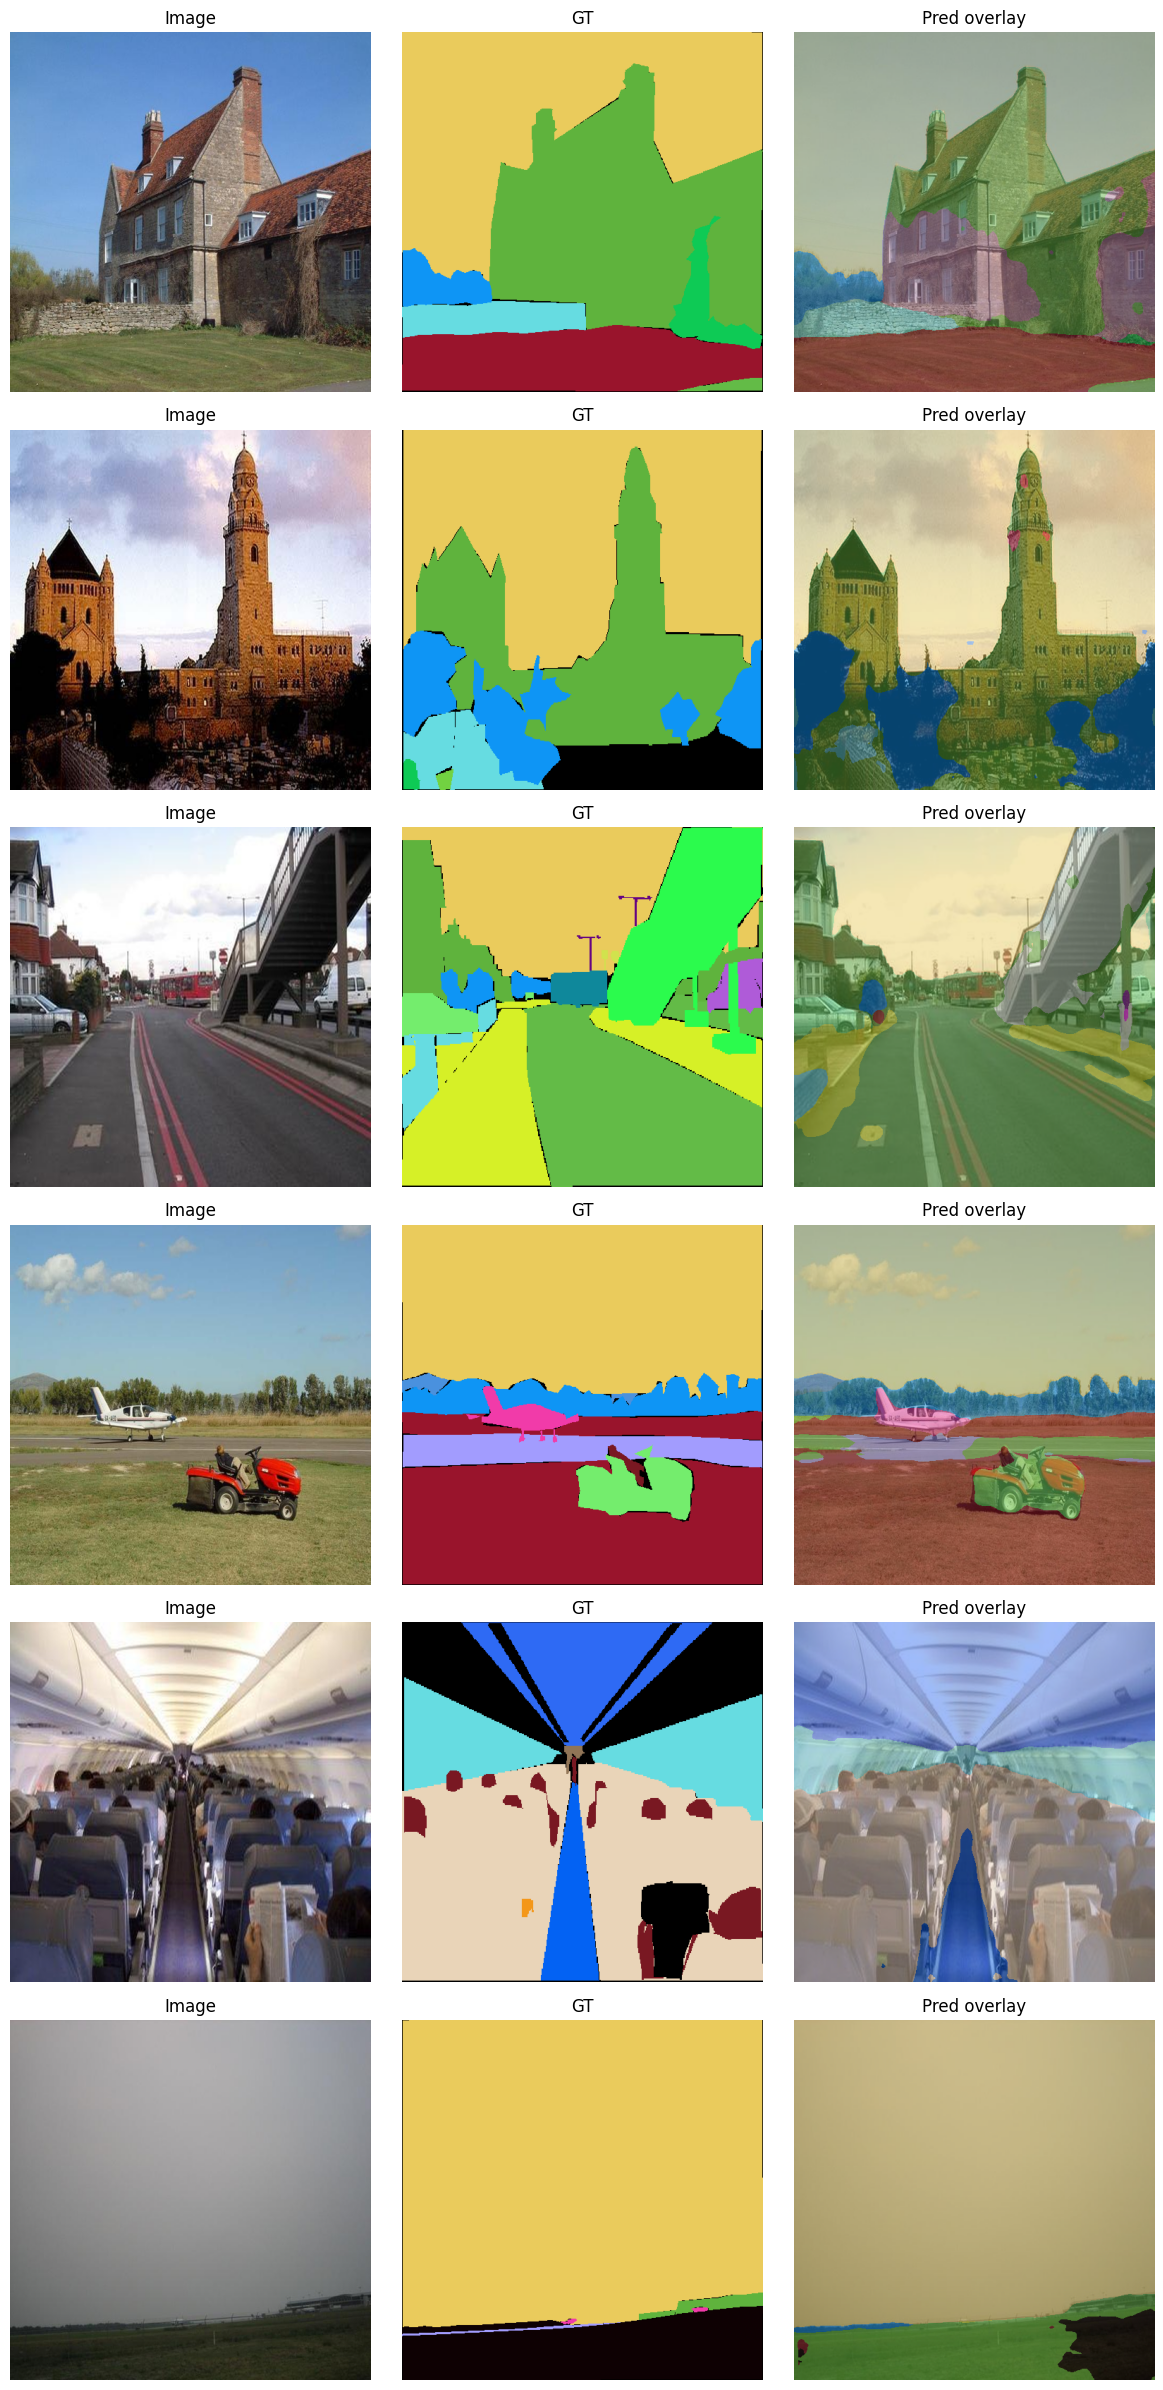

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from pathlib import Path

NUM_SHOW = 6
DEVICE = CONFIG.get("device", torch.device("cuda" if torch.cuda.is_available() else "cpu"))
DATA_DIR = Path(CONFIG["data_dir"])
SPLIT = "validation"  # or "training"
CKPT = Path(CONFIG["best_ckpt"])

cfg = TrainConfig.from_dict(CONFIG)
cfg.device = DEVICE
model = build_segmenter(cfg.model_dict()).to(DEVICE)
model.eval()

if CKPT.is_file():
    try:
        ckpt = torch.load(CKPT, map_location=DEVICE, weights_only=False)
    except TypeError:
        ckpt = torch.load(CKPT, map_location=DEVICE)
    state = ckpt.get("ema", ckpt).get("ema", ckpt["model"]) if isinstance(ckpt.get("ema"), dict) else ckpt["model"]
    if "ema" in ckpt and isinstance(ckpt["ema"], dict) and "ema" in ckpt["ema"]:
        state = ckpt["ema"]["ema"]
    else:
        state = ckpt["model"]
    model.load_state_dict(state, strict=False)
    print(f"Loaded {CKPT}")

np.random.seed(42)
PALETTE = np.random.randint(0, 255, (150, 3), dtype=np.uint8)

def colorize_mask(mask: np.ndarray, ignore_index: int = 255) -> np.ndarray:
    h, w = mask.shape
    out = np.zeros((h, w, 3), dtype=np.uint8)
    valid = mask != ignore_index
    out[valid] = PALETTE[mask[valid] % 150]
    return out

def denorm(img_chw: torch.Tensor) -> np.ndarray:
    mean = torch.tensor([0.485, 0.456, 0.406], device=img_chw.device).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225], device=img_chw.device).view(3, 1, 1)
    x = (img_chw * std + mean).clamp(0, 1).permute(1, 2, 0).cpu().numpy()
    return (x * 255).astype(np.uint8)

@torch.no_grad()
def predict(img_tensor: torch.Tensor) -> np.ndarray:
    x = img_tensor.unsqueeze(0).to(DEVICE)
    if CONFIG.get("use_tta", False):
        logits = predict_with_tta(
            model, x,
            scales=cfg.tta_scales,
            flip=cfg.tta_flip,
        )
    else:
        logits = model(x)["seg_logits"]
    return logits.argmax(1).squeeze(0).cpu().numpy()

img_paths = sorted((DATA_DIR / "images" / SPLIT).glob("*.jpg"))[:NUM_SHOW]

fig, axes = plt.subplots(NUM_SHOW, 3, figsize=(12, 4 * NUM_SHOW))
if NUM_SHOW == 1:
    axes = np.expand_dims(axes, 0)

for i, img_path in enumerate(img_paths):
    mask_path = DATA_DIR / "annotations" / SPLIT / f"{img_path.stem}.png"
    img_pil = Image.open(img_path).convert("RGB").resize(
        (CONFIG["img_size"], CONFIG["img_size"]), Image.LANCZOS
    )
    mask_pil = Image.open(mask_path).resize(
        (CONFIG["img_size"], CONFIG["img_size"]), Image.NEAREST
    )

    img_t = torch.from_numpy(np.array(img_pil)).permute(2, 0, 1).float() / 255.0
    gt = np.array(mask_pil).astype(np.int32) - 1
    gt[gt < 0] = CONFIG["ignore_index"]

    pred = predict(img_t)
    rgb = np.array(img_pil)
    gt_rgb = colorize_mask(gt, CONFIG["ignore_index"])
    pred_rgb = colorize_mask(pred, CONFIG["ignore_index"])
    overlay = (0.55 * rgb + 0.45 * pred_rgb).astype(np.uint8)

    axes[i, 0].imshow(rgb)
    axes[i, 0].set_title("Image")
    axes[i, 1].imshow(gt_rgb)
    axes[i, 1].set_title("GT")
    axes[i, 2].imshow(overlay)
    axes[i, 2].set_title("Pred overlay")
    for j in range(3):
        axes[i, j].axis("off")

plt.tight_layout()
plt.show()